In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd

from shapely.geometry import LineString, MultiLineString
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from shapely.geometry import box
import matplotlib.colors as mcolors

from dask import delayed, compute
from tqdm import tqdm
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar
# import psutil
# import logging

# ============================
# User settings
# ============================

# Generator site list
gen_csv = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/gen_info.csv")

boco_ds = "/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/boco_wind_vec.nc"
clust_ds = "/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/cluster_wind_vec.nc"

output_dir = '/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_hourly_composites'

In [2]:
extent=[140, 155, -42, -28]
step = 2

lon_min, lon_max, lat_min, lat_max = extent

In [3]:
client = Client(n_workers=12,
    threads_per_worker=1,
    memory_limit=f"{int(5)}GB"
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 12
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43199,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40661,Total threads: 1
Dashboard: /proxy/45759/status,Memory: 4.66 GiB
Nanny: tcp://127.0.0.1:40655,


2025-09-02 16:31:55,470 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 8b65d4f1b4a178b5bb0ce765b447810e initialized by task ('rechunk-merge-rechunk-split-rechunk-transfer-3257fad60d515d05802e4bdaf3415922', 0, 1, 4, 7, 1, 6) executed on worker tcp://127.0.0.1:43751
2025-09-02 16:31:55,475 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 5369203cde73284f13412a5e099033a6 initialized by task ('rechunk-merge-rechunk-split-rechunk-transfer-3257fad60d515d05802e4bdaf3415922', 0, 2, 3, 1, 3, 4) executed on worker tcp://127.0.0.1:34425
2025-09-02 16:31:55,539 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle f9b876e7015955b40b2fc77e5e7b317a initialized by task ('rechunk-merge-rechunk-split-rechunk-transfer-3257fad60d515d05802e4bdaf3415922', 0, 0, 4, 7, 0, 6) executed on worker tcp://127.0.0.1:43751
2025-09-02 16:31:55,560 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3ab98a846da5b1718c275d2d6637fd0c initialized by task ('rechunk-merge-rechunk-split

In [4]:
# def setup_dask_client(
#     workload_type="io",
#     max_workers=None,
#     reserve_mem_gb=50,
#     max_mem_gb=None,
#     dashboard=True
# ):

#     logical_cores = psutil.cpu_count(logical=True)
#     total_memory_gb = psutil.virtual_memory().total / 1e9

#     if max_workers is None:
#         max_workers = logical_cores

#     if max_mem_gb is None:
#         max_mem_gb = total_memory_gb

#     usable_mem_gb = max_mem_gb - reserve_mem_gb

#     if workload_type == "cpu":
#         threads_per_worker = 1
#         n_workers = min(max_workers, logical_cores)
#     elif workload_type == "io":
#         threads_per_worker = 8
#         n_workers = max(1, logical_cores // threads_per_worker)
#     else:  # "mixed"
#         threads_per_worker = 4
#         n_workers = max(1, logical_cores // threads_per_worker)

#     memory_per_worker = usable_mem_gb // n_workers

#     print(f"Number of workers = {n_workers}")
#     print(f"Number of threads per worker = {threads_per_worker}")
#     print(f"Memory per worker = {memory_per_worker}")

#     # Suppress distributed worker memory warnings
#     logging.getLogger("distributed.worker.memory").setLevel(logging.ERROR)

#     # Optionally suppress all Dask logs
#     logging.getLogger("dask").setLevel(logging.ERROR)

#         # Start client without verbose messages
#     client = Client(n_workers=n_workers,
#         threads_per_worker=threads_per_worker,
#         memory_limit=f"{int(memory_per_worker)}GB"
#     )

#     return client

# client = setup_dask_client(workload_type="cpu")
# client

In [5]:
cluster = ['TARALGA1','CROOKWF2',
            'GULLRWF1',
            'GULLRWF2',
            'GUNNING1',
            'BANGOWF1',
            'BANGOWF2',
            'COLWF01',
            'WOODLWN1',
            'BOCORWF1']

cluster = gen_csv[gen_csv['DUID'].isin(cluster)][['DUID','lat','lon']]

In [6]:
ds = xr.open_mfdataset(boco_ds, chunks='auto', engine='h5netcdf', parallel=True)
ds = ds.chunk({'time': -1, 'lat': 50, 'lon': 50})

# Convert to Australia/Sydney
local_time = (
    pd.DatetimeIndex(ds.time.values)
    .tz_localize("UTC")
    .tz_convert("Australia/Sydney")
)

# Drop tzinfo so xarray can store it
local_time_naive = local_time.tz_localize(None)

# Assign back to dataset
ds = ds.assign_coords(time=local_time_naive)
ds

<xarray.Dataset> Size: 32GB
Dimensions:  (time: 2832, lat: 646, lon: 1082)
Coordinates:
  * lon      (lon) float64 9kB 88.48 88.59 88.7 88.81 ... 207.2 207.3 207.4
  * lat      (lat) float64 5kB -57.97 -57.86 -57.75 -57.64 ... 12.76 12.87 12.98
    height   float64 8B ...
    crs      int32 4B ...
  * time     (time) datetime64[ns] 23kB 2015-12-19T11:00:00 ... 2023-12-12T10...
Data variables:
    ua100m   (time, lat, lon) float64 16GB dask.array<chunksize=(2832, 50, 50), meta=np.ndarray>
    va100m   (time, lat, lon) float64 16GB dask.array<chunksize=(2832, 50, 50), meta=np.ndarray>
Attributes: (12/59)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-1H.json
    productive_version:        34f247b
    variable_version:          v20240809
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    date_modified:             2024-10-11T01:43:51Z
    date_metadata_modified:    2024-10-11T01:43:51Z
    history:                   Mon Aug 05 04:51:48 2024: /g/data/access/ngm/m...
    references:                https://doi.org/10.25914/1x6g-2v48
    license:                   https://doi.org/10.25914/1x6g-2v48
    acknowledgement:           The production of BARRA2 was supported with fu...

In [7]:
def plot_frame(u, v, lat, lon, t, output_dir='/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/',
               quiver_scale=None, extent=[140, 155, -42, -28], cluster=cluster, highlight_id='BOCORWF1'):
    """
    Plot wind vectors with optional cluster points.
    
    cluster: DataFrame with columns ['ID', 'lat', 'lon']
    highlight_id: specific ID to highlight in red
    """
    speed = np.sqrt(u**2 + v**2)
    plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, lw=1.5)
    ax.add_feature(cfeature.BORDERS, linestyle='-', lw=1.5)
    ax.add_feature(cfeature.STATES, linestyle='-', lw=1.5)
    
    # Contour of wind speed
    plt.contourf(lon, lat, speed, cmap='cividis', transform=ccrs.PlateCarree())
    plt.colorbar(label='Wind speed (m/s)')
    
    # Quiver vectors
    plt.quiver(lon, lat, u, v, scale=quiver_scale, color='white', transform=ccrs.PlateCarree())
    
    # Plot cluster points
    if cluster is not None:
        # All points in orange
        ax.scatter(cluster['lon'], cluster['lat'], color="orange", alpha=0.6, s=50, label="Wind Farms", zorder=5, transform=ccrs.PlateCarree())
        
        # Highlight one point in red
        if highlight_id is not None and highlight_id in cluster['DUID'].values:
            highlight_point = cluster.loc[cluster['DUID'] == highlight_id]
            ax.scatter(highlight_point['lon'], highlight_point['lat'], 
                       color="red", alpha=0.6, s=80, label=f"ID {highlight_id}", zorder=6,
                       transform=ccrs.PlateCarree())

    plt.title(f'Wind vectors at {str(t)}')
    
    filename = make_filename(t, output_dir)
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    return filename


def make_filename(t, output_dir, prefix="wind"):
    try:
        # If t is datetime-like, use date formatting
        dt_str = np.datetime_as_string(t, unit='m')
        dt_str = dt_str.replace('-', '')[2:8] + '_' + dt_str[11:13] + dt_str[14:16]
    except Exception:
        # If it's just an index/hour, format as hour
        if isinstance(t, (int, np.integer)):
            dt_str = f"hour{t:02d}"
        else:
            dt_str = str(t).replace(":", "").replace(" ", "_")
    
    return os.path.join(output_dir, f"{prefix}_{dt_str}.png")


In [8]:
# Crop to extent
ds_subset = ds.sel(**{
    'lon': slice(lon_min, lon_max),
    'lat': slice(lat_min, lat_max)
})

ds_subset

<xarray.Dataset> Size: 783MB
Dimensions:  (time: 2832, lat: 127, lon: 136)
Coordinates:
  * lon      (lon) float64 1kB 140.1 140.2 140.3 140.4 ... 154.7 154.8 154.9
  * lat      (lat) float64 1kB -41.91 -41.8 -41.69 ... -28.27 -28.16 -28.05
    height   float64 8B ...
    crs      int32 4B ...
  * time     (time) datetime64[ns] 23kB 2015-12-19T11:00:00 ... 2023-12-12T10...
Data variables:
    ua100m   (time, lat, lon) float64 391MB dask.array<chunksize=(2832, 4, 31), meta=np.ndarray>
    va100m   (time, lat, lon) float64 391MB dask.array<chunksize=(2832, 4, 31), meta=np.ndarray>
Attributes: (12/59)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-1H.json
    productive_version:        34f247b
    variable_version:          v20240809
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    date_modified:             2024-10-11T01:43:51Z
    date_metadata_modified:    2024-10-11T01:43:51Z
    history:                   Mon Aug 05 04:51:48 2024: /g/data/access/ngm/m...
    references:                https://doi.org/10.25914/1x6g-2v48
    license:                   https://doi.org/10.25914/1x6g-2v48
    acknowledgement:           The production of BARRA2 was supported with fu...

In [9]:
# Lazy hourly mean
hourly_composite =  ds_subset.groupby("time.hour").mean()

# Compute in parallel
with ProgressBar():
    hourly_composite = hourly_composite.compute()
    hourly_composite = hourly_composite.assign_coords(hour=("hour", np.arange(24)))

In [10]:
# # Write to NetCDF using compute=False
# delayed_obj = hourly_composite.to_netcdf(
#                 "/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/hourly_uv_composite.nc",
#                 engine="h5netcdf",
#                 compute=False)

# # Trigger computation with Dask
# with ProgressBar():
#     delayed_obj.compute()

In [11]:
lon_min, lon_max, lat_min, lat_max = extent

for i in range(len(hourly_composite.hour)):
        u = hourly_composite['ua100m'].isel(hour=i)[::step, ::step]
        v = hourly_composite['va100m'].isel(hour=i)[::step, ::step]
        lat = hourly_composite['lat'][::step].values
        lon = hourly_composite['lon'][::step].values
        t = hourly_composite.hour[i].values
        
        plot_frame(u, v, lat, lon, t, output_dir, 250, extent)

In [12]:
lat_subset = hourly_composite['lat'].where(
    (hourly_composite['lat'] >= lat_min) & (hourly_composite['lat'] <= lat_max),
    drop=True
    ).values

lon_subset = hourly_composite['lon'].where(
    (hourly_composite['lon'] >= lon_min) & (hourly_composite['lon'] <= lon_max),
    drop=True
    ).values

for i in range(len(hourly_composite.hour)):
    u_sub = hourly_composite['ua100m'].isel(hour=i).sel(
        lat=lat_subset, lon=lon_subset
    ).values[::step, ::step]

    v_sub = hourly_composite['va100m'].isel(hour=i).sel(
        lat=lat_subset, lon=lon_subset
    ).values[::step, ::step]

    # Also subsample lat/lon to match u/v
    lat_sub = lat_subset[::step]
    lon_sub = lon_subset[::step]

    t = hourly_composite.hour[i].values

    plot_frame(u_sub, v_sub, lat_sub, lon_sub, t, output_dir, 250, extent)

In [13]:
def calc_divergence(ds):
    """
    Compute divergence of u/v on a spherical Earth using xarray.
    ds should be a Dataset with dimensions lat x lon (or time x lat x lon).
    """
    R = 6371000  # Earth radius in meters
    
    # lat_rad shape (lat,)
    lat_rad = np.deg2rad(ds['lat'].values)
    
    dx_1d = np.gradient(ds['lon'].values) * (np.pi/180) * R
    dx2d = dx_1d[None, :] * np.cos(lat_rad[:, None])  # shape (lat, lon)
    
    dy2d = np.gradient(ds['lat'].values) * (np.pi/180) * R
    dy2d = dy2d[:, None]  # shape (lat, 1) to broadcast with u/v

    # Compute divergence
    divergence = (ds['ua100m'].differentiate('lon') / dx2d +
                  ds['va100m'].differentiate('lat') / dy2d)
    
    return divergence

In [17]:
def plot_divergence_frame(divergence, lat, lon, t, cluster=cluster, highlight_id='BOCORWF1',
                          shapefile_gdf=None,
                          output_dir='/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite',
                          extent=extent):
    """
    Plot scalar divergence with optional cluster points and contour shapefile.
    """
    fig, ax = plt.subplots(figsize=(10,8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Base map
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.STATES, linestyle='-')
    
    # Divergence field
    # Symmetric normalization around zero
    norm = mcolors.TwoSlopeNorm(vmin=np.nanmin(divergence),
                                vcenter=0,
                                vmax=np.nanmax(divergence))
    
    cf = ax.contourf(lon, lat, divergence, cmap='coolwarm', levels=21, norm=norm,
                     transform=ccrs.PlateCarree(), zorder=1)
    plt.colorbar(cf, ax=ax, label='Divergence (1/s)')
    
    # --- Contours (from shapefile) ---
    if shapefile_gdf is not None and not shapefile_gdf.empty:
        for geom in shapefile_gdf.geometry:
            ax.add_geometries([geom], crs=ccrs.PlateCarree(),
                              facecolor='none', edgecolor='black',
                              linewidth=0.5, zorder=3)
    
    # Cluster points
    if cluster is not None:
        ax.scatter(cluster['lon'], cluster['lat'], color="orange", edgecolor='black', s=50,
                   label="Wind Farms", zorder=4, transform=ccrs.PlateCarree())
        if highlight_id is not None and highlight_id in cluster['DUID'].values:
            highlight_point = cluster.loc[cluster['DUID'] == highlight_id]
            ax.scatter(highlight_point['lon'], highlight_point['lat'],
                       color="red", edgecolor='black', s=60,
                       label=f"ID {highlight_id}", zorder=5, transform=ccrs.PlateCarree())
    
    plt.title(f'Composite of divergence at hour {str(t)}')
    
    # Save
    filename = make_filename(t, output_dir)
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return filename

In [18]:
# Load shapefile
gdf = gpd.read_file('/g/data/ng72/ms5578/ID_HW_BARRA/data/raw/contours/aus25cgd_l.shp').to_crs(epsg=4326)
bbox = box(lon_min, lon_max, lat_min, lat_max)
gdf_clip = gdf[gdf.geometry.intersects(bbox)]

In [19]:
output_dir = '/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_hourly_composites/R2_divergence_composite'

# Subset dataset
ds_subset = hourly_composite.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
    )

lat_subset = ds_subset['lat'].values
lon_subset = ds_subset['lon'].values

# Loop over each time step
for i in range(len(ds_subset['hour'])):
    ds_time = ds_subset.isel(hour=i)
    
    # Compute divergence for this timestep
    div = calc_divergence(ds_time)
    
    lat_t = div['lat'].values
    lon_t = div['lon'].values
    div_t = div.values
    
    t = ds_time['hour'].values
    
    filename = plot_divergence_frame(div_t, lat_t, lon_t, t,
                                 cluster=cluster,
                                 shapefile_gdf=gdf)
    
    print(f'Saved divergence plot: {filename}')

Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite/wind_0.png
Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite/wind_1.png
Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite/wind_2.png
Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite/wind_3.png
Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite/wind_4.png
Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite/wind_5.png
Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite/wind_6.png
Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_divergence_composite/wind_7.png
Saved divergence plot: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/R2_diverg

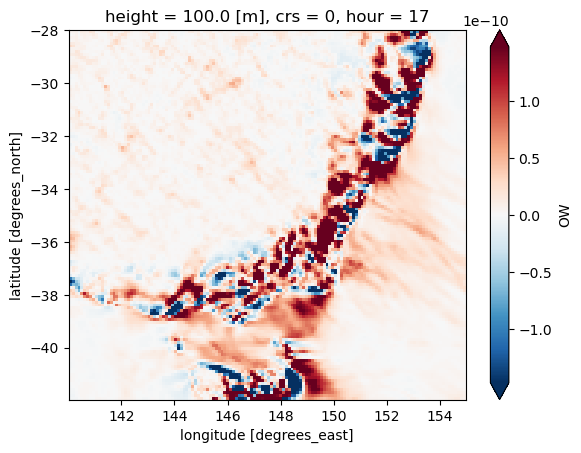

In [20]:
def okubo_weiss(ds, u_name="ua100m", v_name="va100m", lat_name="lat", lon_name="lon"):
    R = 6371000.0
    lat_vals = ds[lat_name].values
    lon_vals = ds[lon_name].values
    lat_rad = np.deg2rad(lat_vals)

    dlat = np.gradient(lat_vals) * np.pi/180 * R
    dlon = np.gradient(lon_vals) * np.pi/180 * R

    # dx/dy 2D arrays matching full grid
    dx2d = xr.DataArray(dlon[None, :] * np.cos(lat_rad[:, None]),
                        dims=[lat_name, lon_name],
                        coords={lat_name: lat_vals, lon_name: lon_vals})
    dy2d = xr.DataArray(dlat[:, None] * np.ones(len(lon_vals)),
                        dims=[lat_name, lon_name],
                        coords={lat_name: lat_vals, lon_name: lon_vals})

    du_dlon = ds[u_name].differentiate(lon_name) * np.pi/180
    du_dlat = ds[u_name].differentiate(lat_name) * np.pi/180
    dv_dlon = ds[v_name].differentiate(lon_name) * np.pi/180
    dv_dlat = ds[v_name].differentiate(lat_name) * np.pi/180

    dudx = du_dlon / dx2d
    dudy = du_dlat / dy2d
    dvdx = dv_dlon / dx2d
    dvdy = dv_dlat / dy2d

    s_n = dudx - dvdy
    s_s = dudy + dvdx
    omega = dvdx - dudy
    OW = s_n**2 + s_s**2 - omega**2

    return xr.Dataset({"s_n": s_n, "s_s": s_s, "omega": omega, "OW": OW})
    
# Compute OW for a 2D slice
ds_slice = hourly_composite.isel(hour=17)
ow_ds = okubo_weiss(ds_slice, u_name="ua100m", v_name="va100m")

# Extract OW field
OW = ow_ds['OW']
OW_plot = OW.where(~np.isnan(OW))
vmax = np.nanpercentile(np.abs(OW.values), 95)
OW.plot(cmap='RdBu_r', vmin=-vmax, vmax=vmax)



In [21]:
R = 6371000  # Earth radius in meters
    
# lat_rad shape (lat,)
lat_rad = np.deg2rad(hourly_composite['lat'].values)

# dx along longitude, in meters
dx_1d = np.gradient(hourly_composite['lon'].values) * (np.pi/180) * R
dx2d = dx_1d[None, :] * np.cos(lat_rad[:, None])  # shape (lat, lon)

# dy along latitude, in meters
dy2d = np.gradient(hourly_composite['lat'].values) * (np.pi/180) * R
dy2d = dy2d[:, None]  # shape (lat, 1) to broadcast

# Compute curl (z-component)
curl_z = (hourly_composite['va100m'].differentiate('lon') / dx2d -
          hourly_composite['ua100m'].differentiate('lat') / dy2d)

for t in range(24):
    plot_divergence_frame(curl_z[t,:,:], hourly_composite['lat'].values, hourly_composite['lon'].values, t, cluster=cluster, highlight_id='BOCORWF1',
                              shapefile_gdf=None,
                              output_dir='/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/curl_R2',
                              extent=extent)
